In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np 
import joblib
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, roc_curve,f1_score

In [6]:
# Preprocessing pipeline
preprocessing = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Ct_for_preprocessing')

#Models
rf_full_feat = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Final_Rf_model_trained_on_full_features')
rf_reduced_feat = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Final_rf_model')
xgb = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Final_xgb_model')
lr = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Final_lr_model')
gb = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Final_gb_model')

In [7]:
# Evaluation processed data 
X_test = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\data\phase4_Models_evalutaion\Evaluation_Ready_data.csv')
X_test = X_test.iloc[:,1:]

y_test = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Evaluation_Ready_data_labels.csv')
y_test = y_test.iloc[:,1:]

In [8]:
X_test.head()

,ord_enc__term,ord_enc__sub_grade,ord_enc__inq_last_6mths_bin,ord_enc__total_acc_bin,ord_enc__bin_annual_inc,ord_enc__bin_int_ratec,ord_enc__bin_dti,ord_enc__bin_revol_util,nom_enc__home_ownership_OWN,nom_enc__home_ownership_RENT,nom_enc__home_ownership_UNSPECIFIED,nom_enc__verification_status_Source Verified,nom_enc__verification_status_Verified,nom_enc__purpose_group_Debt Management,nom_enc__purpose_group_Home & Property,nom_enc__purpose_group_Personal Expenses,nom_enc__purpose_group_Vehicle & Major Purchases,scaling__loan_amnt,remainder__delinq_2yrs_flag,remainder__emp_status_unverifiable
0,0.0,6.0,0.0,2.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-0.424428,0.0,1.0
1,0.0,20.0,2.0,4.0,1.0,3.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.424428,1.0,0.0
2,0.0,18.0,2.0,5.0,2.0,3.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.321654,0.0,0.0
3,0.0,7.0,2.0,0.0,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-1.046162,0.0,0.0
4,0.0,10.0,1.0,3.0,2.0,2.0,4.0,3.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.175734,1.0,0.0


In [9]:
rf_reduced_feat.feature_names_in_

array(['ord_enc__term', 'ord_enc__sub_grade',
       'ord_enc__inq_last_6mths_bin', 'ord_enc__total_acc_bin',
       'ord_enc__bin_annual_inc', 'ord_enc__bin_int_ratec',
       'ord_enc__bin_dti', 'ord_enc__bin_revol_util',
       'nom_enc__home_ownership_OWN', 'nom_enc__home_ownership_RENT',
       'nom_enc__purpose_group_Vehicle & Major Purchases',
       'scaling__loan_amnt', 'remainder__delinq_2yrs_flag',
       'remainder__emp_status_unverifiable'], dtype=object)

In [10]:
def evaluation(x,y,model):
    #Recall
    r = recall_score(y,model.predict(x))

    #Precision
    p = precision_score(y,model.predict(x))

    #Accuracy
    a = accuracy_score(y,model.predict(x))

    #F1
    f1 = f1_score(y,model.predict(x))

    #roc_auc
    roc = roc_auc_score(y,model.predict_proba(x)[:,1])

    metrics = [r,p,a,f1,roc]

    return metrics
    


In [11]:
# metrics 
m_rf_reduced = evaluation(X_test[['ord_enc__term', 'ord_enc__sub_grade',
       'ord_enc__inq_last_6mths_bin', 'ord_enc__total_acc_bin',
       'ord_enc__bin_annual_inc', 'ord_enc__bin_int_ratec',
       'ord_enc__bin_dti', 'ord_enc__bin_revol_util',
       'nom_enc__home_ownership_OWN', 'nom_enc__home_ownership_RENT',
       'nom_enc__purpose_group_Vehicle & Major Purchases',
       'scaling__loan_amnt', 'remainder__delinq_2yrs_flag',
       'remainder__emp_status_unverifiable']],y_test,rf_reduced_feat)
m_rf_full = evaluation(X_test,y_test,rf_full_feat)
m_xgb = evaluation(X_test,y_test,xgb)
m_gb = evaluation(X_test,y_test,gb)
m_lr = evaluation(X_test,y_test,lr)

In [12]:
evaluation_matrix = np.vstack([m_lr, m_xgb,m_rf_full,m_rf_reduced,m_gb])

In [13]:
Evaluation_df = pd.DataFrame(np.round(evaluation_matrix*100,2),
                              columns = ['Recall', 'Precision', 'Accuracy', 'F1 Score', 'ROC - AUC Score'],
                              index = ['Logistic Regression', 'XGboost','Random Forest on full data',
                                       'Random Forest on reduced data', 'Gradient Boosting'])
Evaluation_df

,Recall,Precision,Accuracy,F1 Score,ROC - AUC Score
Logistic Regression,71.83,28.21,59.99,40.51,70.06
XGboost,71.15,27.77,59.43,39.95,69.60
Random Forest on full data,69.57,27.03,58.61,38.93,68.64
Random Forest on reduced data,72.32,26.44,56.59,38.72,68.47
Gradient Boosting,65.97,29.04,62.98,40.33,69.61



## Observations

- **Recall:** Random Forest (reduced) achieves the highest recall (72.32), followed closely by Logistic Regression (71.83).  
- **Precision:** Gradient Boosting leads with 29.04, indicating fewer false positives compared to others.  
- **Accuracy:** Gradient Boosting shows the highest accuracy (62.98).  
- **F1 Score:** Logistic Regression (40.51) and Gradient Boosting (40.33) perform best, balancing recall and precision.  
- **ROC-AUC:** Logistic Regression has the strongest discrimination ability (70.06).

---

## Next Steps

These results highlight trade-offs between models:
- Logistic Regression and Gradient Boosting stand out in different ways.  
- Random Forest (reduced) offers the highest recall, which may be useful if catching defaults is the top priority.  

Further evaluation will help determine which model aligns best with the business objectives.


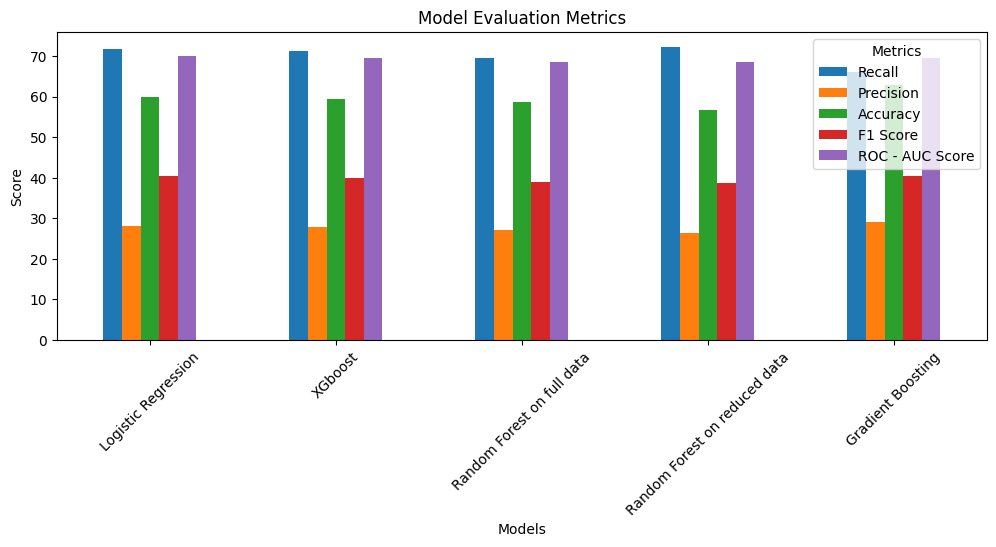

In [14]:
Evaluation_df.plot(kind='bar', figsize=(12,4))
plt.title("Model Evaluation Metrics")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation =45)
plt.legend(title="Metrics")
plt.show()



XGBoost — Top 5 Features
                   Feature  Importance
0   ord_enc__bin_int_ratec   34.588593
1       ord_enc__sub_grade   26.604017
2            ord_enc__term   12.005644
3  ord_enc__bin_annual_inc    6.467113
4         ord_enc__bin_dti    5.753175


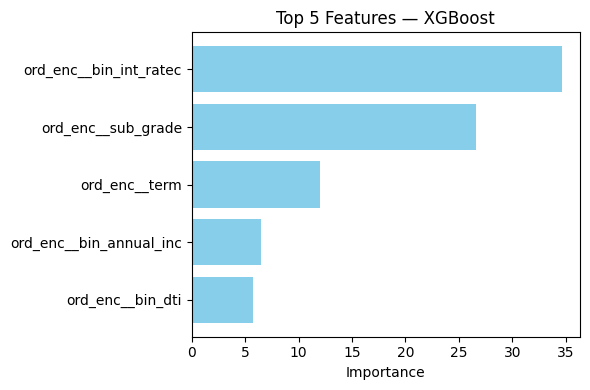


Random Forest (full) — Top 5 Features
                   Feature  Importance
0       ord_enc__sub_grade   60.077453
1   ord_enc__bin_int_ratec   25.165456
2            ord_enc__term    6.946825
3  ord_enc__bin_annual_inc    4.487608
4         ord_enc__bin_dti    3.053540


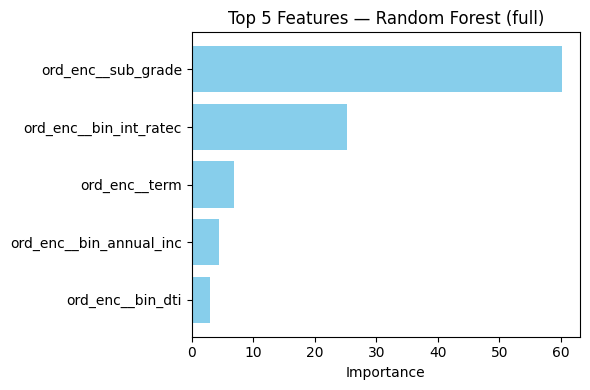


Gradient Boosting — Top 5 Features
                   Feature  Importance
0       ord_enc__sub_grade   64.429801
1  ord_enc__bin_annual_inc    9.518893
2   ord_enc__bin_int_ratec    9.392943
3         ord_enc__bin_dti    6.740374
4            ord_enc__term    5.660053


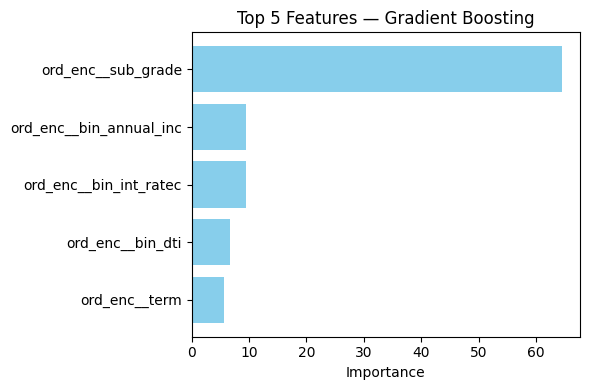


Random Forest (reduced) — Top 5 Features
                   Feature  Importance
0       ord_enc__sub_grade   73.939791
1   ord_enc__bin_int_ratec   15.724137
2  ord_enc__bin_annual_inc    5.841381
3            ord_enc__term    2.329591
4         ord_enc__bin_dti    2.165101


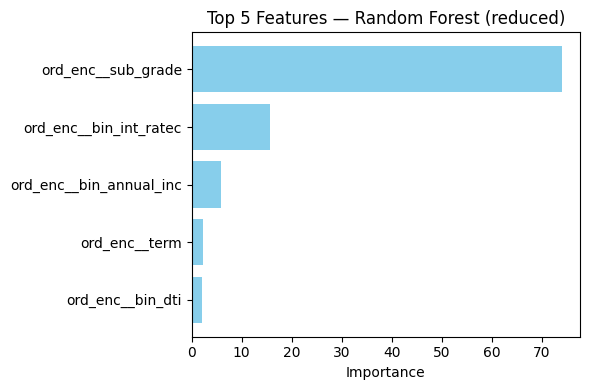

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Models list and names
models = [lr, xgb, rf_full_feat, gb, rf_reduced_feat]
model_names = [
    "Logistic Regression", 
    "XGBoost", 
    "Random Forest (full)", 
    "Gradient Boosting", 
    "Random Forest (reduced)"
]

# Looping  through models and plottting top 5 features
for name, model in zip(model_names, models):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_*100
        features = model.feature_names_in_
        
        # top 5 indices
        top_idx = np.argsort(importances)[-5:][::-1]
        
        # Creating DataFrame
        df_top5 = pd.DataFrame({
            "Feature": features[top_idx],
            "Importance": importances[top_idx]
        })
        
        print(f"\n{name} — Top 5 Features")
        print(df_top5)
        
        # Plot bar chart
        plt.figure(figsize=(6,4))
        plt.barh(df_top5["Feature"], df_top5["Importance"], color="skyblue")
        plt.gca().invert_yaxis()  # highest importance at top
        plt.title(f"Top 5 Features — {name}")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()



Logistic Regression — Top 5 Features
                                            Feature  Importance  Coefficient
0  nom_enc__purpose_group_Vehicle & Major Purchases   67.933951    -0.679340
1            nom_enc__purpose_group_Debt Management   60.625917    -0.606259
2          nom_enc__purpose_group_Personal Expenses   50.177356    -0.501774
3            nom_enc__purpose_group_Home & Property   50.085208    -0.500852
4                remainder__emp_status_unverifiable   46.493681     0.464937
5                                     ord_enc__term   42.530889     0.425309
6                           ord_enc__bin_annual_inc   31.483420    -0.314834
7                            ord_enc__bin_int_ratec   19.733325     0.197333
8                      nom_enc__home_ownership_RENT   15.946062     0.159461
9               nom_enc__home_ownership_UNSPECIFIED   15.131869     0.151319


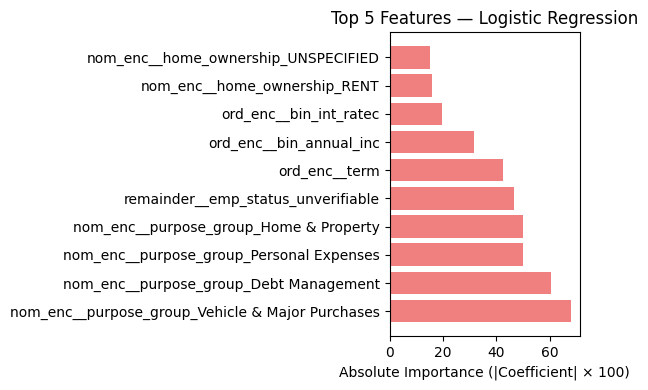

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Logistic Regression model
model = models[0]
name = "Logistic Regression"

# model coeff
coeffs = model.coef_.ravel()
features = model.feature_names_in_

# Taking absolute value for importance 
importances = np.abs(coeffs) * 100

# pickingg top 10 indices
top_idx = np.argsort(importances)[-10:][::-1]

# Create DataFrame
df_top5_lr = pd.DataFrame({
    "Feature": features[top_idx],
    "Importance": importances[top_idx],
    "Coefficient": coeffs[top_idx]  # keeping original sign for interpretation
})

print(f"\n{name} — Top 5 Features")
print(df_top5_lr)

# Plot bar chart
plt.figure(figsize=(6,4))
plt.barh(df_top5_lr["Feature"], df_top5_lr["Importance"], color="lightcoral")
plt.title(f"Top 5 Features — {name}")
plt.xlabel("Absolute Importance (|Coefficient| × 100)")
plt.tight_layout()
plt.show()


# Feature Importance Analysis

We examined the most influential predictors across Logistic Regression and tree-based models.  
The patterns reveal different modeling philosophies: Logistic Regression distributes weight across multiple categorical and borrower-related variables, while tree-based models concentrate importance on a few dominant credit risk indicators.

---

## Logistic Regression (Top 10 Features)
Logistic Regression highlights a **broader set of features**, with coefficients (positive and negative) shaping the probability of default.  
- Loan purpose categories (*Vehicle & Major Purchases*, *Debt Management*, *Personal Expenses*, *Home & Property*) emerge as strong signals, mostly with **negative coefficients**, suggesting lower default risk compared to the baseline.  
- Borrower credibility markers like *employment status unverifiable* and *home ownership (RENT/UNSPECIFIED)* carry **positive coefficients**, indicating higher risk.  
- Classic financial variables (*loan term*, *annual income*, *interest rate category*) also contribute meaningfully, though less dominant than purpose categories.  

This spread shows Logistic Regression’s tendency to **balance multiple behavioral and financial dimensions**, offering interpretability and nuanced insights.

---

## Tree-Based Models (XGBoost, Random Forest, Gradient Boosting)
Across all tree-based models, a consistent pattern emerges:
- **Loan sub-grade** is the single most dominant predictor, often accounting for the majority of importance.  
- **Interest rate category** is the second most influential, reinforcing the link between pricing and risk.  
- Secondary features like *loan term*, *annual income*, and *debt-to-income ratio* appear repeatedly but with much smaller weights.  

This concentration reflects the **hierarchical nature of decision trees**, where a few strong splits explain most of the variance.

---

## Random Forest (Reduced Features)
The reduced Random Forest is particularly striking:
- It leans almost entirely on **sub-grade**, with importance exceeding 70%.  
- Interest rate category is the only other substantial contributor, while income, term, and DTI play minimal roles.  
- By narrowing the feature space, the model becomes **oversimplified**, capturing only a subset of the drivers of default risk.  
- While efficient, this approach risks **missing broader behavioral and financial signals** that Logistic Regression and Gradient Boosting capture.

---

## Overall Insights
- **Sub-grade and interest rate category** dominate tree-based models, reflecting their strong predictive power in credit risk.  
- **Logistic Regression distributes importance more evenly**, highlighting borrower purpose and credibility factors alongside financial metrics.  
- The **reduced Random Forest illustrates the trade-off of simplicity vs. completeness**: fewer features make the model easier to interpret but risk oversimplification.  

Together, these analyses show that while tree-based models excel at capturing strong hierarchical splits, Logistic Regression provides a **broader interpretive lens**, incorporating diverse borrower and loan attributes into its risk assessment.


In [17]:
rf_reduced_inputs = ['ord_enc__term', 'ord_enc__sub_grade',
       'ord_enc__inq_last_6mths_bin', 'ord_enc__total_acc_bin',
       'ord_enc__bin_annual_inc', 'ord_enc__bin_int_ratec',
       'ord_enc__bin_dti', 'ord_enc__bin_revol_util',
       'nom_enc__home_ownership_OWN', 'nom_enc__home_ownership_RENT',
       'nom_enc__purpose_group_Vehicle & Major Purchases',
       'scaling__loan_amnt', 'remainder__delinq_2yrs_flag',
       'remainder__emp_status_unverifiable']

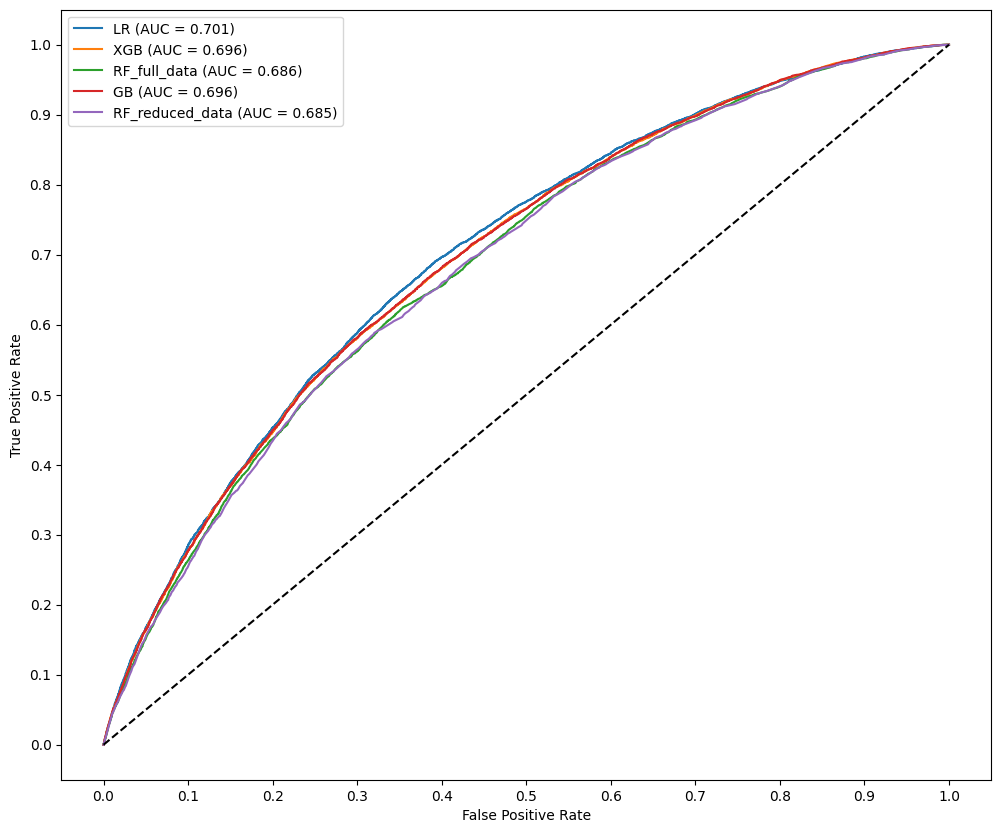

Optimal thresholds (Youden’s J): [np.float64(0.5166794591760401), np.float64(0.5568385720252991), np.float64(0.5518168742579557), np.float64(0.5315603055209451), np.float64(0.5654525949404313)]


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc

models = [lr, xgb, rf_full_feat, gb, rf_reduced_feat]
labels = ['LR','XGB','RF_full_data','GB','RF_reduced_data']
thres = []

plt.figure(figsize=(12,10))

for i, m in enumerate(models):
    label = labels[i]
    if label == 'RF_reduced_data':
        fpr, tpr, thresholds = roc_curve(y_test, m.predict_proba(X_test[rf_reduced_inputs])[:,1])
    else:
        fpr, tpr, thresholds = roc_curve(y_test, m.predict_proba(X_test)[:,1])
    
    # Youden’s J statistic
    thres.append(thresholds[np.argmax(tpr - fpr)])
    
    # AUC
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

# Diagonal line
plt.plot([0,1],[0,1], color='black', linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xticks(np.linspace(0,1,11))
plt.yticks(np.linspace(0,1,11))
plt.legend()
plt.show()

print("Optimal thresholds (Youden’s J):", thres)


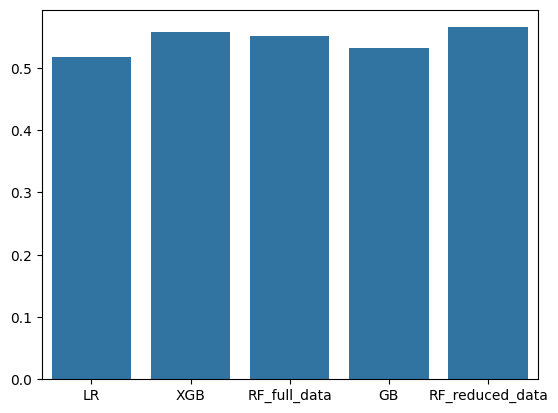

,models,Optimal_thres
0,LR,0.516679
1,XGB,0.556839
2,RF_full_data,0.551817
3,GB,0.531560
4,RF_reduced_data,0.565453


In [22]:
roc_optimal_thresh = thres
sns.barplot(x= labels , y = roc_optimal_thresh)
plt.show()

pd.DataFrame({'models' : labels,
              'Optimal_thres' : roc_optimal_thresh})

# Aggrement level testing

In [23]:
Unlabel_df = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\data\phase4_Models_evalutaion\final_testing_on_unlabeld_dta\data_for_testing.csv')
Unlabel_df = Unlabel_df.iloc[:,1:]

In [24]:
Unlabel_df
data = preprocessing.transform(Unlabel_df.drop('loan_status.1',axis=1))

In [25]:
processed_unlabel_df = pd.DataFrame(data, columns = preprocessing.get_feature_names_out())

In [26]:
processed_unlabel_df['loan_status'] = Unlabel_df['loan_status.1']

In [27]:
processed_unlabel_df['XGB_pred'] = xgb.predict_proba(processed_unlabel_df.iloc[:,:20])[:,1]
processed_unlabel_df['GB_pred'] = gb.predict_proba(processed_unlabel_df.iloc[:,:20])[:,1]
processed_unlabel_df['LR_pred'] = lr.predict_proba(processed_unlabel_df.iloc[:,:20])[:,1]
processed_unlabel_df['RF_full_data_pred'] = rf_full_feat.predict_proba(processed_unlabel_df.iloc[:,:20])[:,1]
processed_unlabel_df['RF_redu_pred'] = rf_reduced_feat.predict_proba(processed_unlabel_df[rf_reduced_inputs])[:,1]

In [28]:
processed_unlabel_df.head()

,ord_enc__term,ord_enc__sub_grade,ord_enc__inq_last_6mths_bin,ord_enc__total_acc_bin,ord_enc__bin_annual_inc,ord_enc__bin_int_ratec,ord_enc__bin_dti,ord_enc__bin_revol_util,nom_enc__home_ownership_OWN,nom_enc__home_ownership_RENT,...,nom_enc__purpose_group_Vehicle & Major Purchases,scaling__loan_amnt,remainder__delinq_2yrs_flag,remainder__emp_status_unverifiable,loan_status,XGB_pred,GB_pred,LR_pred,RF_full_data_pred,RF_redu_pred
0,1.0,9.0,0.0,5.0,2.0,2.0,3.0,2.0,0.0,1.0,...,0.0,-1.294856,0.0,1.0,Current,0.586369,0.550860,0.647955,0.461215,0.423060
1,1.0,14.0,1.0,1.0,2.0,3.0,4.0,4.0,0.0,1.0,...,0.0,-0.797469,0.0,1.0,Current,0.723818,0.707907,0.806693,0.679836,0.655440
2,1.0,14.0,1.0,4.0,1.0,3.0,4.0,3.0,0.0,1.0,...,0.0,-0.424428,0.0,1.0,Current,0.736057,0.724850,0.829240,0.680170,0.655440
3,1.0,9.0,3.0,3.0,1.0,2.0,3.0,2.0,0.0,1.0,...,0.0,-0.113560,0.0,1.0,Current,0.656879,0.629856,0.784026,0.518696,0.517162
4,1.0,17.0,1.0,0.0,1.0,3.0,3.0,2.0,0.0,1.0,...,0.0,0.508175,0.0,1.0,Current,0.723936,0.717715,0.917470,0.656296,0.632546


In [29]:
from sklearn.preprocessing import Binarizer
pred = processed_unlabel_df[['XGB_pred','GB_pred','LR_pred','RF_full_data_pred','RF_redu_pred']]

def prediction_for_threshold(threshold = 0.5):
    bin = Binarizer(threshold= threshold).fit(pred)
    after_bin = pd.DataFrame(bin.transform(pred),columns=bin.get_feature_names_out())
    after_bin['loan_status'] = processed_unlabel_df['loan_status']

    for j,i in enumerate(['XGB_pred','GB_pred','LR_pred','RF_full_data_pred','RF_redu_pred']):
        print(f'------------------------------------------{pred.columns[j]}------------------------------------------\n')
        df = pd.crosstab(index =after_bin[i], columns=after_bin['loan_status'])
        df.loc[2,:] = df.sum().values
        df['Total'] = df.sum(axis=1)

        # Renaming index 
        df.index = ['Non Defaulters', 'Defaulters', 'Total']
        print(df.to_string() ,'\n\n\n')

In [50]:
# making data frame for no of defaulter for different thresholds
thresh  = [0.5,0.6,0.7,0.8,0.9]

lr_predicted_defaulter = []
xgb_predicted_defaulter = []
rf_full_feat_predicted_defaulter = []
rf_reduced_feat_predicted_defaulter = []
gb_predicted_defaulter = []

for i in thresh:
    lr_predicted_defaulter.append(np.where(processed_unlabel_df['LR_pred']>= i, 1,0).sum())
    xgb_predicted_defaulter.append(np.where(processed_unlabel_df['XGB_pred']>= i, 1,0).sum())
    rf_full_feat_predicted_defaulter.append(np.where(processed_unlabel_df['RF_full_data_pred']>= i, 1,0).sum())
    rf_reduced_feat_predicted_defaulter.append(np.where(processed_unlabel_df['RF_redu_pred']>= i, 1,0).sum())
    gb_predicted_defaulter.append(np.where(processed_unlabel_df['GB_pred']>= i, 1,0).sum())

threshold_analysis_df =pd.DataFrame({'Thresholds' : thresh,
                                    'LR' : lr_predicted_defaulter,
                                    'XGB' : xgb_predicted_defaulter,
                                    'RF_full_data' : rf_full_feat_predicted_defaulter,
                                    'RF_red_data' : rf_reduced_feat_predicted_defaulter,
                                    'GB' : gb_predicted_defaulter}) 

threshold_analysis_df = threshold_analysis_df.set_index('Thresholds')   
print(threshold_analysis_df)
threshold_analysis_df =pd.DataFrame({'Thresholds' : thresh,
                                    'LR' : lr_predicted_defaulter,
                                    'XGB' : xgb_predicted_defaulter,
                                    'RF_full_data' : rf_full_feat_predicted_defaulter,
                                    'RF_red_data' : rf_reduced_feat_predicted_defaulter,
                                    'GB' : gb_predicted_defaulter}) 


threshold_analysis_df_in_percent = np.round(threshold_analysis_df*100/processed_unlabel_df.shape[0],2)
threshold_analysis_df_in_percent['Thresholds'] = thresh


threshold_analysis_df_in_percent = threshold_analysis_df_in_percent.set_index('Thresholds')   
print('\n\n',threshold_analysis_df_in_percent)


                LR     XGB  RF_full_data  RF_red_data      GB
Thresholds                                                   
0.5         171003  149026        124870       130135  137928
0.6         128384   91953         76663        74466   82495
0.7          81248   33656         22407        26388   27979
0.8          33779     943             0            0     486
0.9           3885       0             0            0       0


                LR    XGB  RF_full_data  RF_red_data     GB
Thresholds                                                
0.5         72.64  63.31         53.05        55.28  58.59
0.6         54.54  39.06         32.57        31.63  35.04
0.7         34.52  14.30          9.52        11.21  11.89
0.8         14.35   0.40          0.00         0.00   0.21
0.9          1.65   0.00          0.00         0.00   0.00


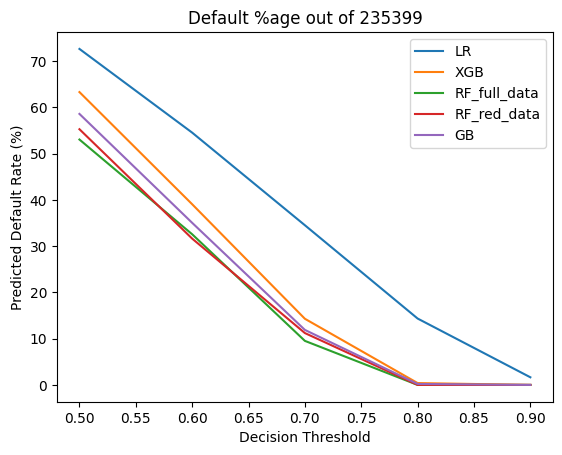

In [57]:

threshold_analysis_df_in_percent.plot(kind = 'line')
plt.title(f'Default %age out of {processed_unlabel_df.shape[0]}')
plt.ylabel('Predicted Default Rate (%)')
plt.xlabel('Decision Threshold')
plt.show()

In [30]:

prediction_for_threshold(0.7)

------------------------------------------XGB_pred------------------------------------------

loan_status      Current  In Grace Period  Late (16-30 days)  Late (31-120 days)     Total
Non Defaulters  193106.0           2415.0              956.0              5266.0  201743.0
Defaulters       31032.0            731.0              261.0              1632.0   33656.0
Total           224138.0           3146.0             1217.0              6898.0  235399.0 



------------------------------------------GB_pred------------------------------------------

loan_status      Current  In Grace Period  Late (16-30 days)  Late (31-120 days)     Total
Non Defaulters  198351.0           2537.0             1012.0              5520.0  207420.0
Defaulters       25787.0            609.0              205.0              1378.0   27979.0
Total           224138.0           3146.0             1217.0              6898.0  235399.0 



------------------------------------------LR_pred----------------------------

## Threshold Stability Analysis

To examine the confidence of each model's predictions, we evaluated how the proportion of loans classified as defaults changes as the decision threshold increases from **0.5** to **0.9**.

### Observations
- As the threshold increased, all models classified fewer loans as defaults, reflecting stricter confidence requirements.
- **Logistic Regression** showed the slowest decline, continuing to predict defaults even at thresholds of **0.8** and **0.9**.
- **XGBoost** and **Gradient Boosting** became increasingly conservative, with very few default predictions above **0.8**.
- Both **Random Forest** models produced no default predictions at thresholds of **0.8** and above, indicating fewer high-confidence default predictions.

### Interpretation
This analysis highlights how each model behaves under different confidence requirements. Logistic Regression maintains a wider range of high-confidence predictions, while the tree-based models produce more conservative probability estimates as the decision threshold increases. These findings complement the calibration analysis and provide additional insight into each model's confidence in predicting default risk.

# Threshold Selection in Default Prediction

In this evaluation, we applied a **probability threshold of 0.7** to classify loans as defaults.  
This threshold was chosen deliberately to reflect a **high-risk perspective**:  
- Only borrowers with a predicted probability of default greater than 70% are flagged as defaulters.  
- The assumption is that stricter classification reduces false positives and focuses on the riskiest cases.  

---

## Why Threshold Matters
- **Lower thresholds (e.g., 0.3–0.5):** More loans would be classified as defaults, increasing recall but also raising false positives.  
- **Higher thresholds (e.g., 0.7–0.8):** Fewer loans are flagged, reducing false positives but potentially missing some true defaults.  
- The choice of threshold depends on **business objectives**:  
  - If the cost of missing a default is very high, a lower threshold may be preferred.  
  - If the cost of wrongly flagging a borrower is high (e.g., denying credit to a good customer), a higher threshold is more appropriate.  

---

## Observations from Current Results
- Across all models, the **logical progression of default probability with payment delay** is preserved:  
  - *Current* → lowest default predictions  
  - *In Grace Period* → slightly higher  
  - *Late (16–30 days)* → higher still  
  - *Late (31–120 days)* → highest default predictions  
- Logistic Regression tends to classify more loans as defaults even at the 0.7 threshold, showing higher sensitivity.  
- Tree-based models (XGBoost, Gradient Boosting, Random Forest) are more conservative, flagging fewer defaults at the same threshold.  
- The **Reduced Random Forest** again demonstrates oversimplification, leaning heavily on fewer features and producing narrower distributions.

---


                    XGB_pred             GB_pred             LR_pred           RF_full_data_pred           RF_redu_pred          
                        mean    median      mean    median      mean    median              mean    median         mean    median
loan_status                                                                                                                      
Current             0.543089  0.554415  0.523390  0.532521  0.607050  0.619211          0.505447  0.518810     0.500709  0.518401
In Grace Period     0.596369  0.612613  0.577541  0.595328  0.673625  0.696656          0.566816  0.590400     0.565302  0.592279
Late (16-30 days)   0.596549  0.609524  0.576731  0.589855  0.672906  0.694361          0.570556  0.590889     0.569991  0.592394
Late (31-120 days)  0.605316  0.622093  0.586513  0.604644  0.681673  0.701980          0.573977  0.595503     0.572867  0.597416


<Axes: xlabel='loan_status'>

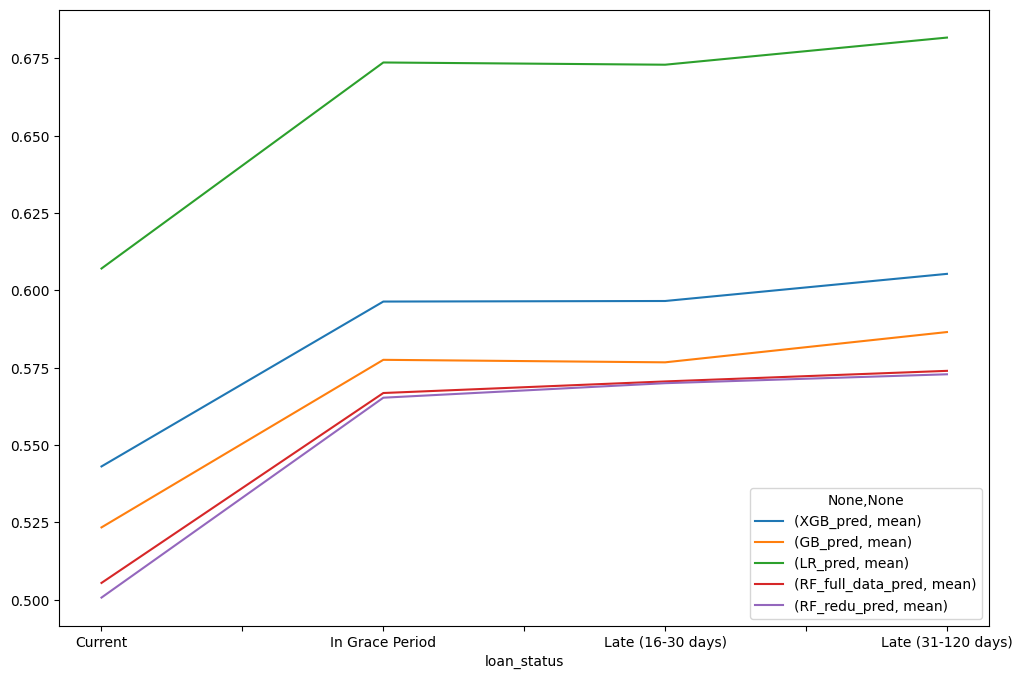

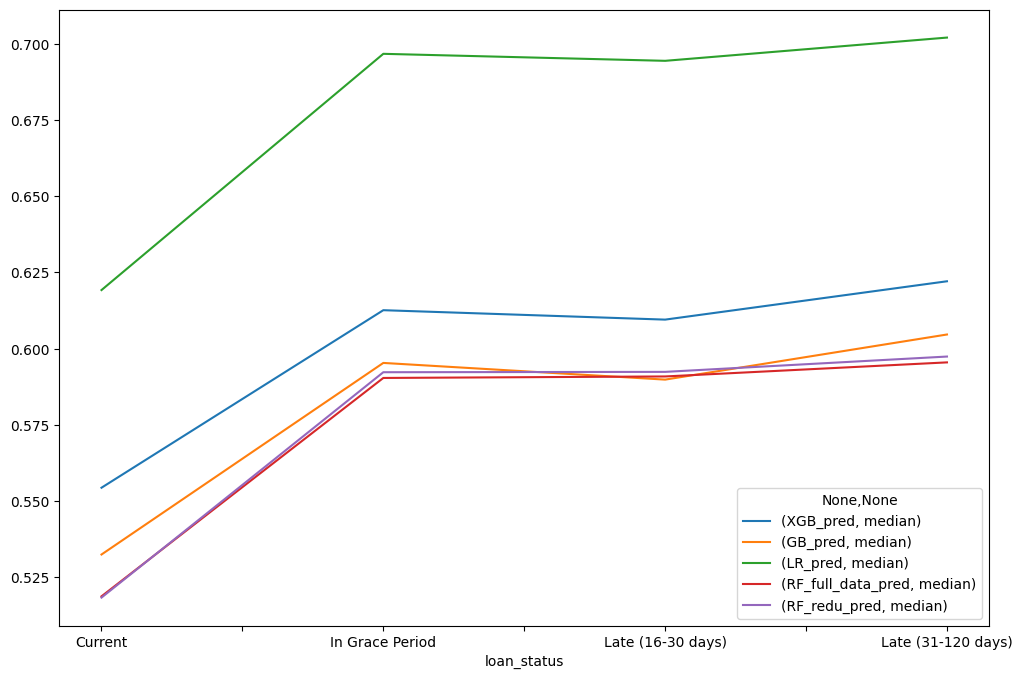

In [ ]:
print(processed_unlabel_df.groupby('loan_status')[['XGB_pred', 'GB_pred', 'LR_pred', 'RF_full_data_pred', 'RF_redu_pred' ]].agg({'median','mean'}).to_string())
processed_unlabel_df.groupby('loan_status')[['XGB_pred', 'GB_pred', 'LR_pred', 'RF_full_data_pred', 'RF_redu_pred' ]].agg({'mean'}).plot(figsize = (12,8))
processed_unlabel_df.groupby('loan_status')[['XGB_pred', 'GB_pred', 'LR_pred', 'RF_full_data_pred', 'RF_redu_pred' ]].agg({'median'}).plot(figsize = (12,8))

# Monotonicity Check of Predicted Probabilities

We evaluated the mean and median predicted probabilities for each loan status category across five models.  
The logical expectation is that **default probability should increase as payment delay lengthens**.  

---

## Results Summary

| Loan Status        | XGBoost (mean/median) | Gradient Boosting | Logistic Regression | Random Forest (Full) | Random Forest (Reduced) |
|--------------------|------------------------|-------------------|---------------------|-----------------------|--------------------------|
| Current            | 0.54 / 0.55           | 0.52 / 0.53       | 0.61 / 0.62         | 0.51 / 0.52           | 0.50 / 0.52              |
| In Grace Period    | 0.60 / 0.61           | 0.58 / 0.60       | 0.67 / 0.70         | 0.57 / 0.59           | 0.57 / 0.59              |
| Late (16–30 days)  | 0.60 / 0.61           | 0.58 / 0.59       | 0.67 / 0.69         | 0.57 / 0.59           | 0.57 / 0.59              |
| Late (31–120 days) | 0.61 / 0.62           | 0.59 / 0.60       | 0.68 / 0.70         | 0.57 / 0.60           | 0.57 / 0.60              |

---

## Observations

- **Monotonicity holds across all models**: predicted probabilities increase as loan status worsens from *Current* → *Grace Period* → *Late (16–30 days)* → *Late (31–120 days)*.  
- **Logistic Regression** consistently produces higher probabilities across all categories, reflecting its sensitivity and tendency to classify more aggressively.  
- **XGBoost and Gradient Boosting** show smoother, gradual increases, aligning well with the expected monotonic progression.  
- **Random Forest (Full and Reduced)** produce lower probabilities overall, with less separation between categories.  
  - The reduced Random Forest, in particular, shows **oversimplification**, with probabilities clustered tightly and less differentiation across loan statuses.  

---

## Key Insight
The monotonicity check confirms that all models respect the logical assumption: **default risk rises with payment delay**.  
However, the **strength of separation varies**:
- Logistic Regression → higher sensitivity, stronger separation.  
- Tree-based models → smoother, more conservative progression.  
- Reduced Random Forest → oversimplified, weaker differentiation.  

This analysis reinforces the importance of **threshold tuning and model calibration** to balance sensitivity and stability in default prediction.


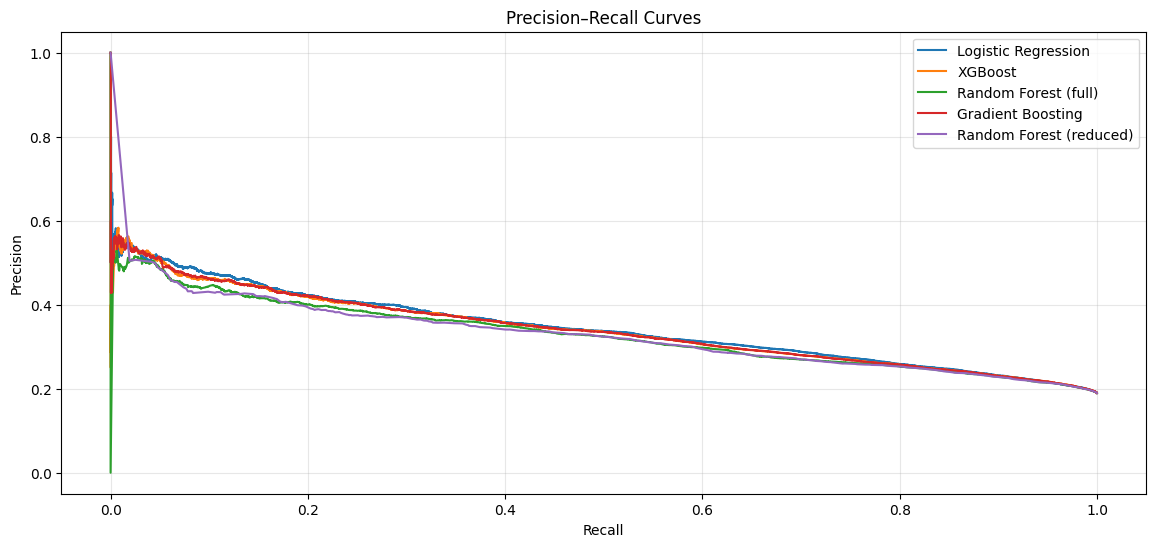

In [117]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Dictionary of predicted probabilities for each model
y_prob_dict = {
    "Logistic Regression": lr.predict_proba(X_test)[:, 1],
    "XGBoost": xgb.predict_proba(X_test)[:, 1],
    "Random Forest (full)": rf_full_feat.predict_proba(X_test)[:, 1],
    "Gradient Boosting": gb.predict_proba(X_test)[:, 1],
    "Random Forest (reduced)": rf_reduced_feat.predict_proba(X_test[['ord_enc__term', 'ord_enc__sub_grade',
       'ord_enc__inq_last_6mths_bin', 'ord_enc__total_acc_bin',
       'ord_enc__bin_annual_inc', 'ord_enc__bin_int_ratec',
       'ord_enc__bin_dti', 'ord_enc__bin_revol_util',
       'nom_enc__home_ownership_OWN', 'nom_enc__home_ownership_RENT',
       'nom_enc__purpose_group_Vehicle & Major Purchases',
       'scaling__loan_amnt', 'remainder__delinq_2yrs_flag',
       'remainder__emp_status_unverifiable']])[:, 1]
}

# True labels
y_true = y_test

# Precision–Recall curves
plt.figure(figsize=(14, 6))
for name, probs in y_prob_dict.items():
    precision, recall, _ = precision_recall_curve(y_true, probs)
    plt.plot(recall, precision, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Precision–Recall Curve Evaluation

We plotted precision–recall curves for all five models to understand how performance changes as the classification threshold varies.  
This analysis helps move beyond a fixed cutoff (e.g., 0.7) and instead evaluate the trade-offs between **precision** (avoiding false positives) and **recall** (catching true defaults).

---

## Key Observations

- **Logistic Regression**  
  - Shows higher recall across thresholds, meaning it captures more defaults.  
  - Precision drops quickly, reflecting a tendency to over-classify defaults.  
  - Useful if the priority is to minimize missed defaults, but risk of false alarms is higher.

- **XGBoost & Gradient Boosting**  
  - Both models trace smoother curves, balancing precision and recall more evenly.  
  - They maintain stronger calibration and consistent trade-offs across thresholds.  
  - Often strong candidates when probability reliability is important.

- **Random Forest (Full Data)**  
  - Similar to boosting models but slightly flatter, showing less separation.  
  - Stable and robust, though less sharp in balancing precision and recall.

- **Random Forest (Reduced Data)**  
  - Curve is weaker, reflecting oversimplification.  
  - Relies heavily on fewer features, leading to narrower probability distributions.  
  - Captures monotonicity but lacks nuance compared to other models.

---

## Insights

- All models respect the logical assumption: **default risk increases with payment delay**.  
- The choice of threshold significantly affects model behavior:
  - Lower thresholds → higher recall, more defaults flagged, but lower precision.  
  - Higher thresholds → higher precision, fewer defaults flagged, but lower recall.  
- The “sweet spot” often lies where the **F1 score** is maximized, balancing precision and recall.

---

## Next Steps

- **Threshold tuning**: Evaluate thresholds across a range (e.g., 0.3–0.8) to identify optimal cutoffs.  
- **Calibration checks**: Confirm predicted probabilities align with observed default frequencies.  
- **Business alignment**: Decide whether the priority is catching all defaults (favoring recall) or minimizing false positives (favoring precision).  

At this stage, the curves provide valuable guidance, but **further tuning and calibration are needed before finalizing a model**.


In [119]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

# Dictionary of predicted probabilities for each model
y_prob_dict = {
    "Logistic Regression": lr.predict_proba(X_test)[:, 1],
    "XGBoost": xgb.predict_proba(X_test)[:, 1],
    "Random Forest (full)": rf_full_feat.predict_proba(X_test)[:, 1],
    "Gradient Boosting": gb.predict_proba(X_test)[:, 1],
    "Random Forest (reduced)": rf_reduced_feat.predict_proba(X_test[['ord_enc__term', 'ord_enc__sub_grade',
       'ord_enc__inq_last_6mths_bin', 'ord_enc__total_acc_bin',
       'ord_enc__bin_annual_inc', 'ord_enc__bin_int_ratec',
       'ord_enc__bin_dti', 'ord_enc__bin_revol_util',
       'nom_enc__home_ownership_OWN', 'nom_enc__home_ownership_RENT',
       'nom_enc__purpose_group_Vehicle & Major Purchases',
       'scaling__loan_amnt', 'remainder__delinq_2yrs_flag',
       'remainder__emp_status_unverifiable']])[:, 1]
}

# True labels
y_true = y_test

# Function to compute best threshold by F1 score
def best_threshold(y_true, y_probs):
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

# Evaluate each model
for name, probs in y_prob_dict.items():
    threshold, f1 = best_threshold(y_true, probs)
    print(f"{name}: Best threshold = {threshold:.3f}, F1 score = {f1:.3f}")


Logistic Regression: Best threshold = 0.546, F1 score = 0.412
XGBoost: Best threshold = 0.566, F1 score = 0.407
Random Forest (full): Best threshold = 0.552, F1 score = 0.398
Gradient Boosting: Best threshold = 0.537, F1 score = 0.407
Random Forest (reduced): Best threshold = 0.565, F1 score = 0.398


# Threshold Optimization Results (F1 Score)

We evaluated the optimal thresholds for each model based on F1 score, rather than fixing the cutoff at 0.7.  
This provides a more balanced view of precision–recall trade-offs.

---

## Best Thresholds per Model

- **Logistic Regression**  
  - Best threshold: **0.546**  
  - F1 score: **0.412**  
  - Slightly lower than 0.7, indicating the model performs better when defaults are flagged earlier.

- **XGBoost**  
  - Best threshold: **0.566**  
  - F1 score: **0.407**  
  - Close to Logistic Regression, with smoother probability separation.

- **Random Forest (Full Data)**  
  - Best threshold: **0.552**  
  - F1 score: **0.398**  
  - Balanced but slightly weaker compared to boosting models.

- **Gradient Boosting**  
  - Best threshold: **0.537**  
  - F1 score: **0.407**  
  - Similar to XGBoost, showing strong calibration and balanced trade-offs.

- **Random Forest (Reduced Data)**  
  - Best threshold: **0.565**  
  - F1 score: **0.398**  
  - Again reflects oversimplification, with weaker performance compared to other models.

---

## Insights
- All models achieve **optimal thresholds between 0.53 and 0.57**, not at the arbitrary 0.7 cutoff.  
- Logistic Regression achieves the highest F1 score (0.412), though XGBoost and Gradient Boosting are very close (0.407).  
- Random Forest models lag slightly behind, with reduced data showing no improvement over the full version.  
- This confirms that **threshold tuning is essential**: fixing at 0.7 would have missed the actual performance peak.

---

## Next Steps
- Consider **calibration plots** (e.g., reliability curves, Brier scores) to check probability accuracy.  
- Align threshold choice with **business priorities**:  
  - If minimizing missed defaults → lean toward Logistic Regression.  
  - If balancing precision and recall → boosting models may be preferable.  
- Final model selection should combine **threshold tuning, calibration, and cost analysis** before deployment.


Logistic Regression: Brier score = 0.2397
XGBoost: Brier score = 0.2356
Random Forest (full): Brier score = 0.2380
Gradient Boosting: Brier score = 0.2212
Random Forest (reduced): Brier score = 0.2386


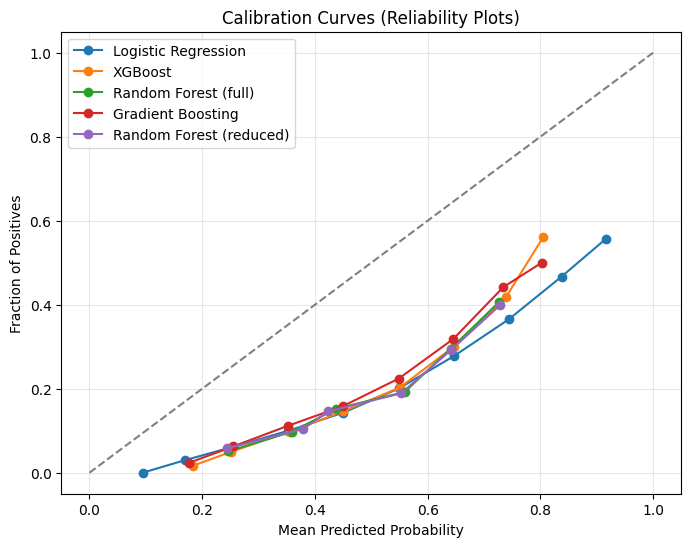

In [121]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Dictionary of predicted probabilities for each model
y_prob_dict = {
    "Logistic Regression": lr.predict_proba(X_test)[:, 1],
    "XGBoost": xgb.predict_proba(X_test)[:, 1],
    "Random Forest (full)": rf_full_feat.predict_proba(X_test)[:, 1],
    "Gradient Boosting": gb.predict_proba(X_test)[:, 1],
    "Random Forest (reduced)": rf_reduced_feat.predict_proba(X_test[['ord_enc__term', 'ord_enc__sub_grade',
       'ord_enc__inq_last_6mths_bin', 'ord_enc__total_acc_bin',
       'ord_enc__bin_annual_inc', 'ord_enc__bin_int_ratec',
       'ord_enc__bin_dti', 'ord_enc__bin_revol_util',
       'nom_enc__home_ownership_OWN', 'nom_enc__home_ownership_RENT',
       'nom_enc__purpose_group_Vehicle & Major Purchases',
       'scaling__loan_amnt', 'remainder__delinq_2yrs_flag',
       'remainder__emp_status_unverifiable']])[:, 1]
}

# True labels
y_true = y_test

plt.figure(figsize=(8, 6))

# Plot calibration curves
for name, probs in y_prob_dict.items():
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name)
    
    # Print Brier score for each model
    brier = brier_score_loss(y_true, probs)
    print(f"{name}: Brier score = {brier:.4f}")

# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curves (Reliability Plots)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Calibration Results (Brier Scores)

We computed Brier scores for all five models to evaluate how well their predicted probabilities align with observed default frequencies.  
Lower Brier scores indicate better calibration (more reliable probabilities).

---

## Model Performance

- **Logistic Regression**  
  - Brier score: **0.2397**  
  - Slightly higher than boosting models, but still acceptable.  
  - Strength: interpretability and broad feature usage.

- **XGBoost**  
  - Brier score: **0.2356**  
  - Good calibration, close to Logistic Regression.  
  - Balanced trade-offs with strong discrimination.

- **Random Forest (Full Data)**  
  - Brier score: **0.2380**  
  - Similar to Logistic Regression, but slightly weaker calibration.  
  - Stable but less sharp.

- **Gradient Boosting**  
  - Brier score: **0.2212**  
  - Best calibration among all models.  
  - Indicates strong probability reliability and balanced performance.

- **Random Forest (Reduced Data)**  
  - Brier score: **0.2386**  
  - Similar to full Random Forest, but oversimplified.  
  - Confirms reduced feature space does not improve calibration.

---

## Insights
- **Gradient Boosting is the most well-calibrated model**, with the lowest Brier score (0.2212).  
- Logistic Regression and XGBoost are close behind, offering strong interpretability and balanced calibration.  
- Random Forest models lag slightly, with reduced data showing no advantage.  
- Calibration confirms that boosting models not only separate defaults well but also produce **trustworthy probabilities**.

---

## Next Steps
- **Finalize model selection**: Gradient Boosting appears strongest overall, but Logistic Regression may still be preferred if interpretability is the top priority.  
- **Threshold application**: Use the optimal thresholds identified earlier (≈0.53–0.56) rather than a fixed 0.7 cutoff.  
- **Business alignment**: Choose the model that best balances recall, precision, and calibration with organizational risk appetite.

---

### ✅ Conclusion
Based on calibration and threshold tuning, **Gradient Boosting is the leading candidate for deployment**, with Logistic Regression as a strong interpretable alternative.


In [ ]:
#

## McNemar's Test

McNemar's test is used to compare the predictions of two classification models on the same test dataset. It determines whether the difference in their classification errors is statistically significant.

## McNemar's Test Algorithm

1. Train two classification models.
2. Generate predictions for both models on the same test dataset.
3. Compare each model's predictions with the true test labels (`y_test`) to determine whether each prediction is correct or incorrect.
4. Construct a **2 × 2 contingency table** based on the correctness of both models.
5. Apply McNemar's test to the contingency table.
6. Compare the **p-value** with the chosen significance level (typically 0.05).
7. Conclude whether the difference in the models' classification errors is statistically significant.
### Hypotheses

- **H₀ (Null Hypothesis):** Both models have the same error rate.
- **H₁ (Alternative Hypothesis):** The models have different error rates.

### Decision Rule

- If **p-value < 0.05**, reject **H₀**. The models differ significantly in their prediction errors.
- If **p-value ≥ 0.05**, fail to reject **H₀**. There is no statistically significant difference between the models.

In [ ]:
# Using threshold = 0.5

# Logistic Regression vs XGBoost
# Logistic Regression vs Gradient Boosting
# Logistic Regression vs Random Forest (Full)
# Logistic Regression vs Random Forest (Reduced)
# XGBoost vs Gradient Boosting
# XGBoost vs Random Forest (Full)
# XGBoost vs Random Forest (Reduced)
# Gradient Boosting vs Random Forest (Full)
# Gradient Boosting vs Random Forest (Reduced)
# Random Forest (Full) vs Random Forest (Reduced)

from statsmodels.stats.contingency_tables import mcnemar


M1 correct  False  True 
M2 correct              
False       16533   2151
True         1893  25481 

0.0001
Reject H0: The models differ significantly in their prediction errors.
LR produces more correct predictions than XGB.
LR performs better.


In [123]:
def mcneymar_test(model1,model2, model1_name , model2_name):
    """
    Perform McNemar's test to compare the prediction errors of two classification models.

    Parameters
    ----------
    model1 : estimator
        First trained classification model.
    
    model2 : estimator
        Second trained classification model.

    model1_name : str
        Name of the first model.

    model2_name : str
        Name of the second model.

    Returns
    -------
    None
        Prints the McNemar test result, indicating whether the difference in
        prediction errors is statistically significant and, if significant,
        identifies the better-performing model.
    """

    # predictions 
    M1 = model1_name
    M2 = model2_name
    m1_pred = model1.predict(X_test)
    m2_pred = model2.predict(X_test)

    # Correct predictions
    m1_correct = (y_test.values.flatten() == m1_pred)
    m2_correct = (y_test.values.flatten() == m2_pred)

    # table
    table = pd.crosstab(index=m2_correct, columns=m1_correct,
                            rownames=['M2 correct'],
                            colnames=['M1 correct'])

    # diag values
    n01 = table.iloc[0,1]
    n10 = table.iloc[1,0]

    # print(table,'\n')

    # MCNEYMAR Test
    result = mcnemar(table)
    p_val = np.round(result.pvalue,4)
    # print(f'{p_val}')

    if p_val < 0.05:
        print('Reject H0: The models differ significantly in their prediction errors.')

        if n01 > n10:
            print(f'{M1} produces more correct predictions than {M2}.\n{M1} performs better.')
        elif n10 > n01:
            print(f'{M2} produces more correct predictions than {M1}.\n{M2} performs better.')
        else:
            print(f'{M1} and {M2} have the same number of unique correct predictions.')
    else:
        print(f'Fail to reject H0: There is no statistically significant difference between {M1} and {M2}.')

In [ ]:
# LR vs all models(except rf_reduced)
model = [lr, xgb, gb, rf_full_feat]
model_name = ['LR', 'XGB', 'GB', 'RF']
for i in range(3):
    mcneymar_test(model1=model[0], model2=model[i+1] , model1_name=model_name[0], model2_name=model_name[i+1])
    print()

# GB > LR > XGB
# GB > LR > RF

for i in range(2):
    mcneymar_test(model1=model[1], model2=model[i+2] , model1_name=model_name[1], model2_name=model_name[i+2])
    print()

# GB > XGB > RF

for i in range(1):
    mcneymar_test(model1=model[2], model2=model[i+3] , model1_name=model_name[2], model2_name=model_name[i+3])
    print()

# GB > RF

Reject H0: The models differ significantly in their prediction errors.
LR produces more correct predictions than XGB.
LR performs better.

Reject H0: The models differ significantly in their prediction errors.
GB produces more correct predictions than LR.
GB performs better.

Reject H0: The models differ significantly in their prediction errors.
LR produces more correct predictions than RF.
LR performs better.

Reject H0: The models differ significantly in their prediction errors.
GB produces more correct predictions than XGB.
GB performs better.

Reject H0: The models differ significantly in their prediction errors.
XGB produces more correct predictions than RF.
XGB performs better.

Reject H0: The models differ significantly in their prediction errors.
GB produces more correct predictions than RF.
GB performs better.




------------------------------------

Overall - GB > LR > XGB > RF 


In [139]:
# predictions 
M1 = 'RF_full'
M2 = 'RF_red'
m1_pred = rf_full_feat.predict(X_test)
m2_pred = rf_reduced_feat.predict(X_test[rf_reduced_inputs])

# Correct predictions
m1_correct = (y_test.values.flatten() == m1_pred)
m2_correct = (y_test.values.flatten() == m2_pred)

# table
table = pd.crosstab(index=m2_correct, columns=m1_correct,
                        rownames=['M2 correct'],
                        colnames=['M1 correct'])

# diag values
n01 = table.iloc[0,1]
n10 = table.iloc[1,0]

print(table,'\n')

# MCNEYMAR Test
result = mcnemar(table)
p_val = np.round(result.pvalue,4)
print(f'{p_val}')

if p_val < 0.05:
    print('Reject H0: The models differ significantly in their prediction errors.')

    if n01 > n10:
        print(f'{M1} produces more correct predictions than {M2}.\n{M1} performs better.')
    elif n10 > n01:
        print(f'{M2} produces more correct predictions than {M1}.\n{M2} performs better.')
    else:
        print(f'{M1} and {M2} have the same number of unique correct predictions.')
else:
    print(f'Fail to reject H0: There is no statistically significant difference between {M1} and {M2}.')



print('\n\n\n------------------------------------\n\nOverall - GB > LR > XGB > RF > RF_reduced ')

M1 correct  False  True 
M2 correct              
False       18823   1170
True          240  25825 

0.0
Reject H0: The models differ significantly in their prediction errors.
RF_full produces more correct predictions than RF_red.
RF_full performs better.



------------------------------------

Overall - GB > LR > XGB > RF > RF_reduced 


### Interpretation

Pairwise McNemar's tests were conducted to compare the classification errors of all evaluated models. All pairwise comparisons produced p-values less than 0.05, indicating statistically significant differences in prediction errors between each pair of models.

The results indicate that:

- Gradient Boosting outperformed Logistic Regression, XGBoost, Random Forest, and the reduced Random Forest model.
- Logistic Regression outperformed XGBoost, Random Forest, and the reduced Random Forest model.
- XGBoost outperformed both the full and reduced Random Forest models.
- The full Random Forest model outperformed the reduced Random Forest model.

Based on these pairwise comparisons, the overall ranking of the models is:

**Gradient Boosting > Logistic Regression > XGBoost > Random Forest > Reduced Random Forest**

These statistical comparisons provide strong evidence that **Gradient Boosting** achieved the best predictive performance among the evaluated classifiers, while the reduced Random Forest model performed the worst. Additionally, the significantly better performance of the full Random Forest model over the reduced Random Forest model suggests that feature reduction resulted in a measurable loss of predictive performance.

# Final Model Comparison

---

## Consolidated Metrics

| Model | Recall | Precision | Accuracy | F1 | ROC-AUC | Brier | Best Threshold |
|---|---|---|---|---|---|---|---|
| Logistic Regression | 71.83% | 28.21% | 59.99% | 0.412 | 70.06% | 0.2397 | 0.546 |
| XGBoost | 71.15% | 27.77% | 59.43% | 0.407 | 69.60% | 0.2356 | 0.566 |
| Gradient Boosting | 65.97% | 29.04% | 62.98% | 0.407 | 69.61% | **0.2212** | 0.537 |
| Random Forest (Full) | 69.57% | 27.03% | 58.61% | 0.398 | 68.64% | 0.2380 | 0.552 |
| Random Forest (Reduced) | 72.32% | 26.44% | 56.59% | 0.398 | 68.47% | 0.2386 | 0.565 |

---

## Evaluation Summary

No single metric was sufficient to identify the best model — selection
was based on five complementary criteria:

- **Predictive performance** — Recall, Precision, Accuracy, F1, ROC-AUC
- **Calibration quality** — Brier Score
- **Threshold optimization** — F1-maximizing threshold from PR curve
- **Monotonicity validation** — agreement analysis on 235,399 active loans
- **Statistical significance** — McNemar's pairwise tests across all models

### Key Findings
- **Gradient Boosting** — lowest Brier score (0.2212), best calibrated
  probabilities, highest precision and accuracy
- **Logistic Regression** — highest F1 (0.412) and ROC-AUC (70.06%)
  but weakest calibration (0.2397)
- **XGBoost** — competitive across all metrics but consistently
  outperformed by GBM on calibration
- **Random Forest (both)** — weakest F1 and calibration across
  all evaluation criteria

McNemar's pairwise tests confirmed all differences are statistically
significant. Final ranking:

**GBM > LR > XGBoost > RF Full > RF Reduced**

---

## Final Model Selection — Gradient Boosting

Although Logistic Regression achieved the highest F1 score, the
improvement over GBM was marginal (0.412 vs 0.407) and came at
the cost of significantly weaker calibration (0.2397 vs 0.2212).

Gradient Boosting was selected as the final model because it:

- Achieved the **best probability calibration** (Brier 0.2212) —
  predicted probabilities most accurately reflect true default rates
- Demonstrated **stable threshold behaviour** — optimal threshold
  (0.537) closest to natural 0.5, least sensitive to threshold choice
- Produced **highest precision (29.04%) and accuracy (62.98%)** —
  most conservative and reliable predictions
- **Passed monotonicity validation** — default probabilities increased
  consistently from Current → Grace Period → Late loans on 235,399
  active borrowers, confirming business validity
- Was **statistically superior** to all competing models based on
  McNemar's test

While GBM shows slightly lower recall at the default threshold
(65.97%), its superior probability calibration makes its risk scores
more trustworthy for downstream decisions — loan pricing, capital
reserve calculations, and portfolio risk monitoring — where the
actual probability value matters more than the binary prediction.

---

## Conclusion

Considering predictive performance, calibration quality, threshold
robustness, monotonicity validation, and statistical significance,
**Gradient Boosting provides the best overall balance among all
evaluated classifiers** and was selected as the final model for
the explainability phase using SHAP.